[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Time-Series-Analysis/blob/main/Quantlets/Ch_05/TSA_ch5_simulation_likelihood/TSA_ch5_simulation_likelihood.ipynb)

# TSA_ch5_simulation_likelihood

Simulated i.i.d. Normal, ARCH(1) and GARCH(1,1) paths with the same unconditional variance; the conditional log-likelihood of a simulated ARCH(1) as a function of alpha for two sample sizes; contours of the GARCH(1,1) log-likelihood over (alpha, beta) with variance targeting.

*Time Series Analysis (TSA), Chapter 5: Conditional volatility: ARCH and GARCH. Author: Daniel Traian Pele.*

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/TSA/Chapter_5'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/TSA - Serii de timp/repo/Quantlets/Ch_05/TSA_ch5_simulation_likelihood


In [2]:
# The arch package (ARCH/GARCH estimation) is not preinstalled in Google Colab: pip install arch
import importlib.util, subprocess, sys
if importlib.util.find_spec('arch') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'arch'])

In [3]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

In [4]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import tsa_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

In [5]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the TSA repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Analysis

In [6]:
import statsmodels.api as sm

from statsmodels.stats.diagnostic import acorr_ljungbox

from arch import arch_model

SEED = 2026

ASSETS = ['sp500', 'bet', 'eurron', 'btc']

NAME = {'sp500': 'S&P 500', 'bet': 'BET', 'eurron': 'EUR/RON', 'btc': 'Bitcoin'}

START = {'sp500': '2000-01-01', 'bet': '2000-01-01', 'eurron': None, 'btc': None}

COLORS = {'sp500': '#1A3A6E', 'bet': '#CD0000', 'eurron': '#2E7D32', 'btc': '#B5853F'}

SCALE = {'eurron': 10}

EPISODES = {'2008': ('2008-09-01', '2009-03-31'), '2020': ('2020-02-15', '2020-05-31')}

OOS_START = '2015-01-01'

REFIT = 250

LAMBDA = 0.94

ALPHA_VAR = 0.01

LB_LAGS = 10

ARCH_LAGS = 5

IG = 0.9995

TERM_DATES = ['2017-11-03', '2020-03-16']

def returns(k, start=None, end=None):
    """Daily log returns in % on the series' own calendar."""
    r = log_returns(k, start or START.get(k)) if end is None else log_returns(k, start or START.get(k), end)
    return r.rename(k)


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def acf_vals(x, nlags):
    """Sample autocorrelations rho_hat(1..nlags) = sum (x_t - m)(x_{t-k} - m) / sum (x_t - m)^2."""
    e = np.asarray(x, float) - np.mean(x)
    s = np.sum(e ** 2)
    return np.array([np.sum(e[k:] * e[:-k]) / s for k in range(1, nlags + 1)])


def ljung_box(x, lags=LB_LAGS, dof=0):
    """Ljung-Box Q(lags) and its p-value (chi-square with lags - dof degrees of freedom)."""
    lb = acorr_ljungbox(pd.Series(np.asarray(x, float)).dropna(), lags=[lags], model_df=dof)
    return float(lb['lb_stat'].iloc[0]), float(lb['lb_pvalue'].iloc[0])


def arch_lm(x, q=ARCH_LAGS):
    """Engle's (1982) ARCH-LM test: regress e_t^2 on a constant and e_{t-1}^2, ..., e_{t-q}^2 (e_t = x_t - mean);
    LM = n R^2 ~ chi-square(q) under no ARCH effects (n = number of regression observations)."""
    e2 = (np.asarray(x, float) - np.mean(x)) ** 2
    y = e2[q:]
    X = np.column_stack([np.ones(len(y))] + [e2[q - j:len(e2) - j] for j in range(1, q + 1)])
    b, *_ = np.linalg.lstsq(X, y, rcond=None)
    u = y - X @ b
    r2 = 1 - np.sum(u ** 2) / np.sum((y - y.mean()) ** 2)
    lm = len(y) * r2
    return {'lm': float(lm), 'r2': float(r2), 'n': len(y), 'p': float(stats.chi2.sf(lm, q)),
            'crit': float(stats.chi2.ppf(0.95, q)), 'b': [float(v) for v in b]}


def fit(r, vol='GARCH', dist='t', o=0, p=1, q=1, mean='Constant', lags=1, last_obs=None, cov_type='robust'):
    """ML estimation with the arch package: constant or AR(lags) mean; GARCH (o = 0), GJR-GARCH (o = 1), EGARCH,
    ARCH(p). The series is multiplied by SCALE (EUR/RON: 10) and the result remembers the factor in res.sc."""
    sc = SCALE.get(r.name, 1)
    kw = dict(mean=mean, lags=lags if mean == 'AR' else 0, dist=dist, rescale=False)
    if vol == 'ARCH':
        am = arch_model(sc * r, vol='ARCH', p=p, **kw)
    elif vol == 'EGARCH':
        am = arch_model(sc * r, vol='EGARCH', p=1, o=1, q=1, **kw)
    else:
        am = arch_model(sc * r, vol='GARCH', p=p, o=o, q=q, **kw)
    res = am.fit(disp='off', last_obs=last_obs, cov_type=cov_type, options={'maxiter': 2000})
    res.sc = sc
    return res


def par(res):
    """Parameters in % units (the estimation scale removed): mu and Const / sc, omega / sc^2 (GARCH, GJR, ARCH)."""
    p = res.params.copy()
    for n in p.index:
        if n in ('mu', 'Const'):
            p[n] = p[n] / res.sc
        elif n == 'omega' and res.model.volatility.__class__.__name__ != 'EGARCH':
            p[n] = p[n] / res.sc ** 2
    return p


def sig(res):
    """Conditional volatility in %."""
    return res.conditional_volatility / res.sc


def persistence(res):
    """alpha + beta (GARCH), alpha + beta + gamma/2 (GJR with symmetric innovations), beta (EGARCH)."""
    p = res.params
    if res.model.volatility.__class__.__name__ == 'EGARCH':
        return float(p['beta[1]'])
    return float(sum(v for n, v in p.items() if n.startswith(('alpha', 'beta'))) + 0.5 * p.get('gamma[1]', 0.0))


def half_life(pers):
    """Days after which half of a variance shock has disappeared: ln 0.5 / ln(persistence)."""
    return float(np.log(0.5) / np.log(pers)) if 0 < pers < 1 else float('inf')


def summary(res, r):
    """Parameters and robust standard errors in % units, persistence, half-life, long-run and sample volatility."""
    p = par(res)
    se = res.std_err.copy()
    for n in se.index:
        if n in ('mu', 'Const'):
            se[n] = se[n] / res.sc
        elif n == 'omega':
            se[n] = se[n] / res.sc ** 2
    pers = persistence(res)
    ppy = periods_per_year(r)
    adj = res.nobs * np.log(res.sc)               # log-likelihood of r_t = log-likelihood of sc r_t + n ln sc
    out = {'n': int(res.nobs), 'first': r.index[0].date().isoformat(), 'ppy': float(ppy),
           'params': {k: float(v) for k, v in p.items()}, 'se': {k: float(v) for k, v in se.items()},
           'loglik': float(res.loglikelihood + adj), 'aic': float(res.aic - 2 * adj), 'bic': float(res.bic - 2 * adj),
           'k': int(len(p)), 'pers': pers, 'hl': half_life(pers), 'vol_sample': float(r.std() * np.sqrt(ppy))}
    if 'omega' in p and res.model.volatility.__class__.__name__ != 'EGARCH' and pers < IG:
        uv = p['omega'] / (1 - pers)
        out['uv'] = float(uv)
        out['vol_lr'] = float(np.sqrt(uv * ppy))
    return out


def ols_ar1(r):
    """AR(1) for the mean by OLS: r_t = c + phi r_{t-1} + e_t; coefficients, classic and HAC-robust t statistics."""
    y, x = r.values[1:], r.values[:-1]
    X = sm.add_constant(x)
    o = sm.OLS(y, X).fit()
    h = sm.OLS(y, X).fit(cov_type='HC0')
    return {'c': float(o.params[0]), 'phi': float(o.params[1]), 'se': float(o.bse[1]), 'se_robust': float(h.bse[1]),
            'resid': pd.Series(o.resid, index=r.index[1:])}


def ar_order(r, pmax=5):
    """AR(p) for the mean with constant variance, p = 0..pmax chosen by BIC on the same observations."""
    bic = {}
    for p in range(pmax + 1):
        am = arch_model(r * SCALE.get(r.name, 1), mean='AR' if p else 'Constant', lags=p, vol='Constant',
                        hold_back=pmax, rescale=False)
        bic[p] = float(am.fit(disp='off').bic)
    return min(bic, key=bic.get), bic


def simulate_garch(n, omega, alpha, beta=0.0, burn=500, seed=SEED, dist='normal', nu=5.0):
    """eps_t = sigma_t z_t, sigma_t^2 = omega + alpha eps_{t-1}^2 + beta sigma_{t-1}^2 (beta = 0: ARCH(1));
    z_t standard Normal or standardised Student-t; returns (eps, sigma)."""
    rng = np.random.default_rng(seed)
    m = n + burn
    z = rng.standard_normal(m) if dist == 'normal' else rng.standard_t(nu, m) * np.sqrt((nu - 2) / nu)
    s2 = np.empty(m)
    e = np.empty(m)
    s2[0] = omega / (1 - alpha - beta)
    e[0] = np.sqrt(s2[0]) * z[0]
    for t in range(1, m):
        s2[t] = omega + alpha * e[t - 1] ** 2 + beta * s2[t - 1]
        e[t] = np.sqrt(s2[t]) * z[t]
    return e[burn:], np.sqrt(s2[burn:])


def fig_simulated(n=1000, save_it=True):
    """Three paths with unconditional variance 1: i.i.d. Normal, ARCH(1) (omega = 0.5, alpha = 0.5) and
    GARCH(1,1) (omega = 0.02, alpha = 0.10, beta = 0.88, values typical of daily equity returns)."""
    rng = np.random.default_rng(SEED)
    paths = {'i.i.d. Normal(0, 1)': rng.standard_normal(n),
             'ARCH(1): omega = 0.5, alpha = 0.5': simulate_garch(n, 0.5, 0.5, 0.0, seed=SEED + 1)[0],
             'GARCH(1,1): omega = 0.02, alpha = 0.10, beta = 0.88': simulate_garch(n, 0.02, 0.10, 0.88, seed=SEED + 2)[0]}
    fig, axes = plt.subplots(3, 1, figsize=(11, 4.8), sharex=True, sharey=True)
    out = {}
    for ax, (lab, x), c in zip(axes, paths.items(), [st.MainBlue, st.IDAred, st.Forest]):
        ax.plot(np.arange(n), x, color=c, lw=0.7, label=lab)
        ax.set_ylabel('value')
        out[lab.split(':')[0]] = {'sd': float(np.std(x)), 'kurt': float(stats.kurtosis(x, fisher=False)),
                                  'max_abs': float(np.max(np.abs(x))), 'acf2_1': float(acf_vals(x ** 2, 1)[0])}
    axes[-1].set_xlabel('time t')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.07, 1, 1))
    save('tsa_ch5_simulated', save_it)
    return out


def arch1_loglik(alpha, x):
    """Conditional Gaussian log-likelihood of ARCH(1) with omega = 1 - alpha (unconditional variance 1):
    l(alpha) = sum_{t>=2} [-0.5 ln s2_t - 0.5 x_t^2 / s2_t] (constant dropped), s2_t = omega + alpha x_{t-1}^2."""
    s2 = (1 - alpha) + alpha * x[:-1] ** 2
    return float(np.sum(-0.5 * np.log(s2) - 0.5 * x[1:] ** 2 / s2))


def fig_lik_arch1(ns=(100, 1000), alpha0=0.5, save_it=True):
    """Log-likelihood of a simulated ARCH(1) (omega = alpha = 0.5) as a function of alpha, for two sample sizes;
    each curve minus its maximum; standard errors from the curvature at the maximum."""
    grid = np.linspace(0.05, 0.95, 181)
    fig, ax = plt.subplots(figsize=(10, 4.0))
    out = {}
    for n, c in zip(ns, [st.MainBlue, st.IDAred]):
        x = simulate_garch(n, 1 - alpha0, alpha0, 0.0, seed=SEED + n)[0]
        ll = np.array([arch1_loglik(a, x) for a in grid])
        res = optimize.minimize_scalar(lambda a: -arch1_loglik(a, x), bounds=(0.001, 0.999), method='bounded')
        ax.plot(grid, ll - ll.max(), color=c, lw=1.6, label=f'n = {n}: log-likelihood minus its maximum')
        ax.axvline(res.x, color=c, ls='--', lw=1.0, label=f'n = {n}: maximum at alpha = {res.x:.3f}')
        h = 1e-4
        d2 = (arch1_loglik(res.x + h, x) - 2 * arch1_loglik(res.x, x) + arch1_loglik(res.x - h, x)) / h ** 2
        out[str(n)] = {'alpha_hat': float(res.x), 'se': float(1 / np.sqrt(-d2))}
    ax.axvline(alpha0, color='black', ls=':', lw=1.2, label=f'true alpha = {alpha0}')
    ax.set_ylim(-40, 2)
    ax.set_xlabel('alpha')
    ax.set_ylabel('log-likelihood minus maximum')
    st.legend_outside_bottom(ax, ncol=2, y=-0.2)
    save('tsa_ch5_lik_arch1', save_it)
    return out


def garch_loglik_vt(a, b, x, s2bar):
    """Gaussian GARCH(1,1) log-likelihood with variance targeting omega = (1 - a - b) s2bar."""
    om = (1 - a - b) * s2bar
    s2 = np.empty(len(x))
    s2[0] = s2bar
    for t in range(1, len(x)):
        s2[t] = om + a * x[t - 1] ** 2 + b * s2[t - 1]
    return float(np.sum(-0.5 * np.log(s2[1:]) - 0.5 * x[1:] ** 2 / s2[1:]))


def fig_lik_garch(ns=(500, 2000), save_it=True):
    """Contours of the log-likelihood of a simulated GARCH(1,1) (omega = 0.1, alpha = 0.1, beta = 0.8) over a grid of
    (alpha, beta), omega set by variance targeting, for n = 500 and n = 2000."""
    A = np.linspace(0.01, 0.30, 59)
    B = np.linspace(0.50, 0.97, 48)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.6), sharey=True)
    out = {}
    cols = [st.Purple, st.MainBlue, st.Teal, st.Forest, st.Amber, st.Orange, st.IDAred]
    for ax, n in zip(axes, ns):
        x = simulate_garch(n, 0.1, 0.1, 0.8, seed=SEED + 7)[0]
        s2bar = float(np.var(x))
        L = np.full((len(B), len(A)), np.nan)
        for i, b in enumerate(B):
            for j, a in enumerate(A):
                if a + b < 0.995:
                    L[i, j] = garch_loglik_vt(a, b, x, s2bar)
        i, j = np.unravel_index(np.nanargmax(L), L.shape)
        lv = np.nanmax(L) - np.array([40, 20, 10, 5, 3, 2, 1])
        cs = ax.contour(A, B, L, levels=lv, colors=cols, linewidths=1.1)
        ax.clabel(cs, fmt=lambda v, m=np.nanmax(L): f'{v - m:.0f}', fontsize=8)
        ax.plot(A[j], B[i], 'o', color=st.IDAred, ms=8, label='maximum on the grid')
        ax.plot(0.1, 0.8, 'x', color='black', ms=9, mew=2, label='true values: alpha = 0.1, beta = 0.8')
        ax.plot(A, 1 - A, color=st.Purple, ls='--', lw=1.2, label='alpha + beta = 1 (IGARCH boundary)')
        ax.set_xlim(A[0], A[-1])
        ax.set_ylim(B[0], B[-1])
        ax.set_title(f'n = {n}: maximum at alpha = {A[j]:.2f}, beta = {B[i]:.2f}', loc='left', fontsize=11)
        ax.set_xlabel('alpha')
        out[str(n)] = {'a_hat': float(A[j]), 'b_hat': float(B[i])}
    axes[0].set_ylabel('beta')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    save('tsa_ch5_lik_garch', save_it)
    return out

## Run

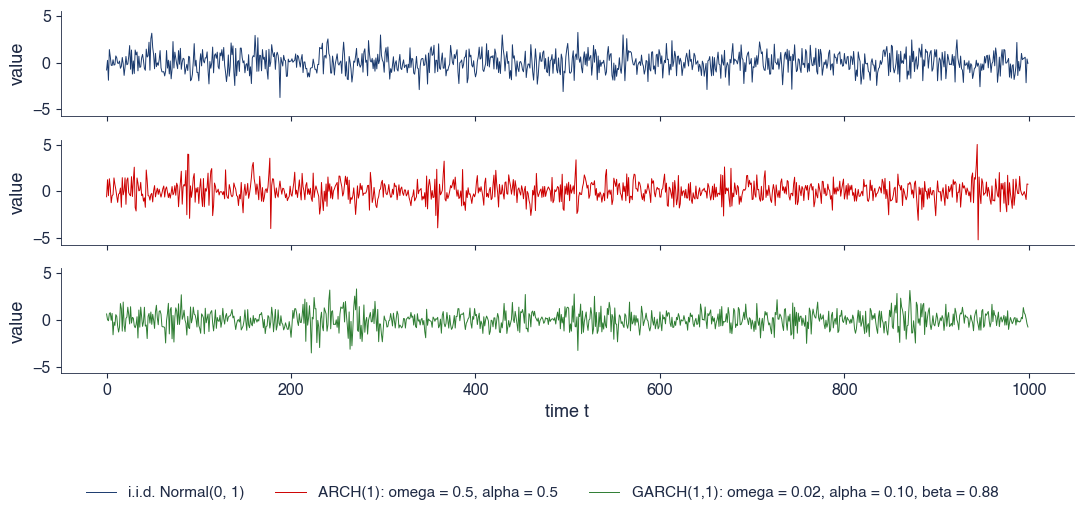

{'i.i.d. Normal(0, 1)': {'sd': 1.0304556065650603, 'kurt': 3.123049004729069, 'max_abs': 3.747413858130894, 'acf2_1': -0.030009910880500677}, 'ARCH(1)': {'sd': 1.0233520220966699, 'kurt': 4.910973401188952, 'max_abs': 5.211144268406423, 'acf2_1': 0.5088330212224601}, 'GARCH(1,1)': {'sd': 0.9274374031785692, 'kurt': 3.740525282563708, 'max_abs': 3.543086950257758, 'acf2_1': 0.06929476661971908}}


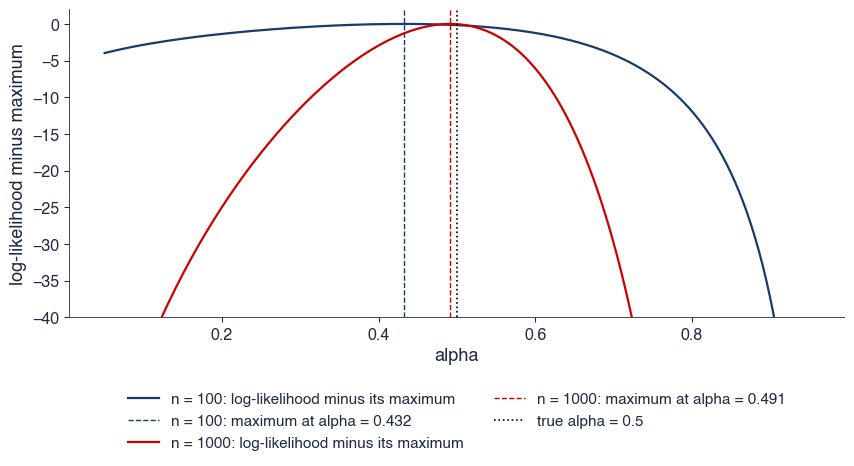

{'100': {'alpha_hat': 0.4321708014832945, 'se': 0.12654232891838452}, '1000': {'alpha_hat': 0.4914830947353353, 'se': 0.035046208171455616}}


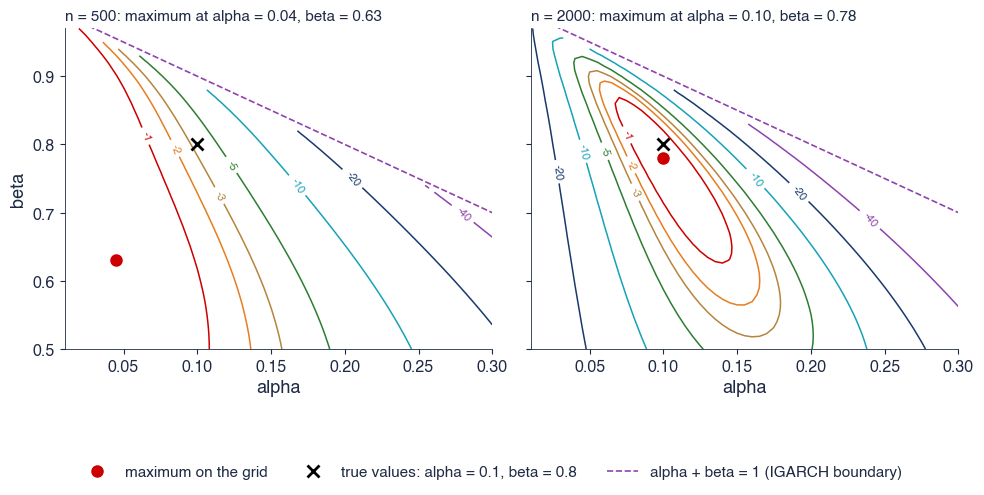

{'500': {'a_hat': 0.045, 'b_hat': 0.63}, '2000': {'a_hat': 0.09999999999999998, 'b_hat': 0.78}}


In [7]:
print(fig_simulated())
print(fig_lik_arch1())
print(fig_lik_garch())

![tsa_ch5_simulated](./tsa_ch5_simulated.png)

Output: `tsa_ch5_simulated.pdf`

![tsa_ch5_lik_arch1](./tsa_ch5_lik_arch1.png)

Output: `tsa_ch5_lik_arch1.pdf`

![tsa_ch5_lik_garch](./tsa_ch5_lik_garch.png)

Output: `tsa_ch5_lik_garch.pdf`